# Visu of experiments for mnist

# A.2

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Load your data into a DataFrame.
# For example, if you have a CSV file:
DATASET = "MNIST"
MODEL = "10x2"
eps = 0.05

channel = 1
data_format = "channels_first"
n_class = 10

# pick A_1 or A_2
EXP = "A_2"

dataframe_repository = "./results/final_version/{}".format(EXP)
filename = "{}_{}_{}".format(DATASET, MODEL, EXP)
dataframe_filename = filename


In [15]:
df = pd.read_csv("{}/{}.csv".format(dataframe_repository, dataframe_filename))

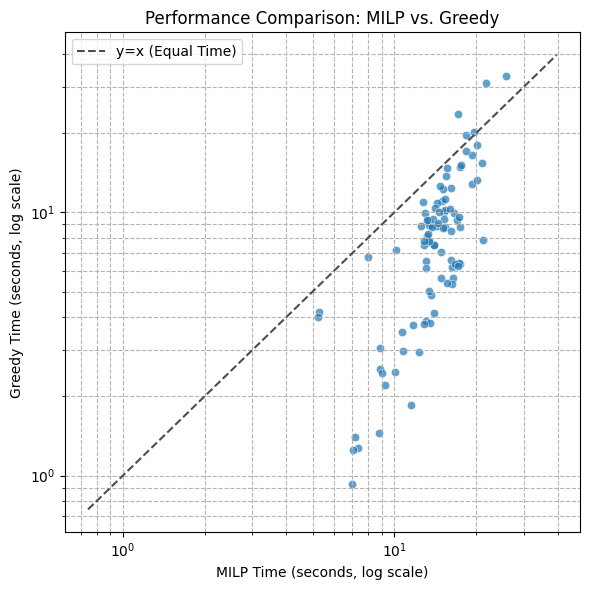

In [16]:
# --- Plot 1: Performance (Time) Comparison ---
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='milp_time', y='greedy_time', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
min_val = min(df['milp_time'].min(), df['greedy_time'].min()) * 0.8
max_val = max(df['milp_time'].max(), df['greedy_time'].max()) * 1.2
plt.plot([min_val, max_val], [min_val, max_val], ls="--", c=".3", label="y=x (Equal Time)")
plt.xlabel("MILP Time (seconds, log scale)")
plt.ylabel("Greedy Time (seconds, log scale)")
plt.title("Performance Comparison: MILP vs. Greedy")
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.savefig("time_comparison.png")
# plt.show() # Use this in a notebook to display the plot

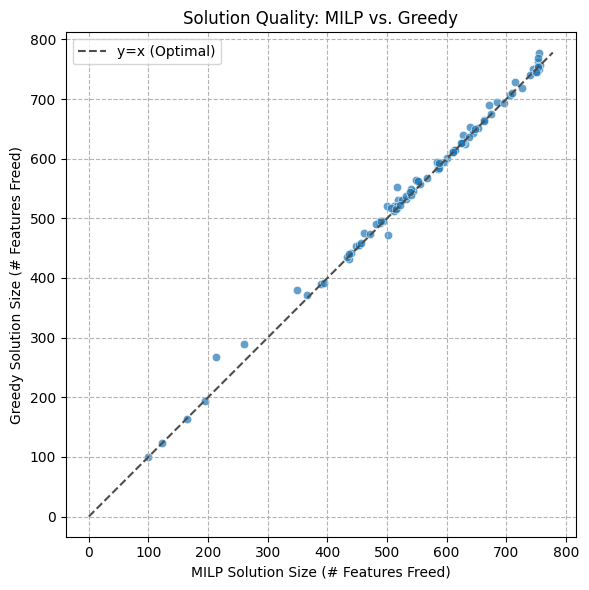

In [17]:
# --- Plot 2: Solution Quality (Size) Comparison ---
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='milp_size', y='greedy_size', alpha=0.7)
max_size = max(df['milp_size'].max(), df['greedy_size'].max())
plt.plot([0, max_size], [0, max_size], ls="--", c=".3", label="y=x (Optimal)")
plt.xlabel("MILP Solution Size (# Features Freed)")
plt.ylabel("Greedy Solution Size (# Features Freed)")
plt.title("Solution Quality: MILP vs. Greedy")
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.axis('equal') # Ensures the plot is square and the y=x line is at 45 degrees
plt.tight_layout()
plt.savefig("size_comparison.png")
# plt.show()

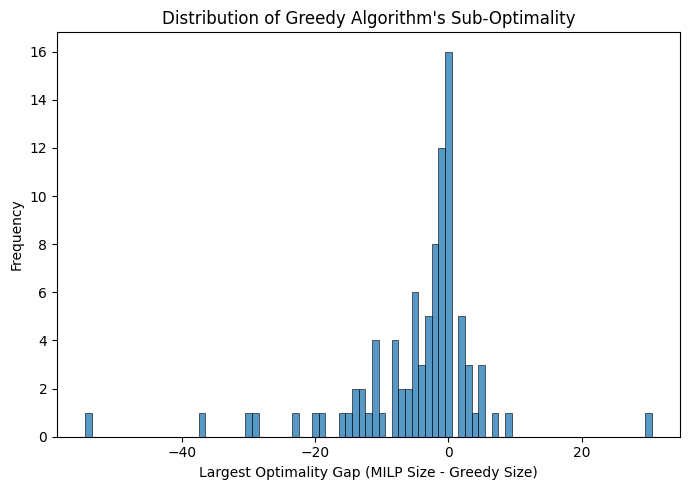

In [18]:
# --- Plot 3: Optimality Gap Distribution ---
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='greedy_2_milp', discrete=True)
plt.xlabel("Largest Optimality Gap (MILP Size - Greedy Size)")
plt.ylabel("Frequency")
plt.title("Distribution of Greedy Algorithm's Sub-Optimality")
plt.tight_layout()
plt.savefig("optimality_gap_histogram.png")
# plt.show()